# Dynamic Asset Allocation via Macroeconomic Regime Switching
**An Empirical Application of Hidden Markov Models in Global Finance**

## Abstract
In this study, the use of unsupervised machine learning is examined for detecting hidden economic states. Through the development of rolling measures of volatility and systemic fear using indicators like the VIX index in conjunction with stock indices, the Gaussian HMM (Hidden Markov Model) is utilized to mathematically classify the past 15 years of financial history into regimes of growth and recession.

## 1. Methodology: The Gaussian Hidden Markov Model

Unlike traditional linear regressions, an HMM assumes the observable market data ($Y_t$) is driven by a latent, unobservable state ($S_t$). We define a two-state model where $S_t \in \{0, 1\}$, representing economic contraction and expansion.

The observation sequence is modeled as a Gaussian distribution dependent on the hidden state:
$$P(Y_t | S_t = j) \sim \mathcal{N}(\mu_j, \Sigma_j)$$

The transition between these macroeconomic regimes is governed by a Markov transition probability matrix, where the probability of moving to a future state depends entirely on the current state:
$$P(S_{t+1} = j | S_t = i) = a_{ij}$$

In [1]:
# 2. Data Engineering
import pandas as pd
import yfinance as yf

# Download the core data
tickers = {"Euro_Stoxx_50": "^STOXX50E", "EUR_USD": "EURUSD=X", "VIX": "^VIX"}
raw_data = pd.DataFrame()

for name, ticker in tickers.items():
    raw_data[name] = yf.download(ticker, start="2010-01-01", end="2026-01-01", progress=False)['Close']

df = raw_data.ffill().dropna()

# Calculate Returns and Engineer Macro Features
df['Stoxx_Return'] = df['Euro_Stoxx_50'].pct_change()
df['VIX_Change'] = df['VIX'].diff()

# Rolling features to smooth out daily noise
df['Stoxx_Vol_14d'] = df['Stoxx_Return'].rolling(window=14).std()
df['VIX_Trend_14d'] = df['VIX_Change'].rolling(window=14).mean()

df = df.dropna()
df.head()

,Euro_Stoxx_50,EUR_USD,VIX,Stoxx_Return,VIX_Change,Stoxx_Vol_14d,VIX_Trend_14d
Date,,,,,,,
2010-01-22,2836.800049,1.414107,27.309999,-0.009238,5.039999,0.009750,0.519286
2010-01-25,2807.300049,1.415008,25.410000,-0.010399,-1.900000,0.009847,0.432857
2010-01-26,2827.739990,1.408232,24.549999,0.007281,-0.860001,0.010338,0.385000
2010-01-27,2787.399902,1.403095,23.139999,-0.014266,-1.410000,0.010600,0.291429
2010-01-28,2737.330078,1.396804,23.730000,-0.017963,0.590000,0.010771,0.400000


In [2]:
# 3. Model Training & Regime Prediction
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings("ignore")

# Initialize the 2-State HMM
model = GaussianHMM(n_components=2, covariance_type="full", n_iter=5000, random_state=42)

# Feed the engineered macro features into the model
features = df[['Stoxx_Return', 'Stoxx_Vol_14d', 'VIX_Trend_14d']].values
model.fit(features)

# Predict the hidden states
df['Regime'] = model.predict(features)

# Ensure Regime 0 is always the high-volatility (Crisis) state
if df[df['Regime'] == 0]['Stoxx_Vol_14d'].mean() < df[df['Regime'] == 1]['Stoxx_Vol_14d'].mean():
    df['Regime'] = 1 - df['Regime']
    
print("Mathematical convergence achieved. Regimes assigned.")

Model is not converging.  Current: 28764.223040616536 is not greater than 28765.488172602647. Delta is -1.2651319861106458


Mathematical convergence achieved. Regimes assigned.


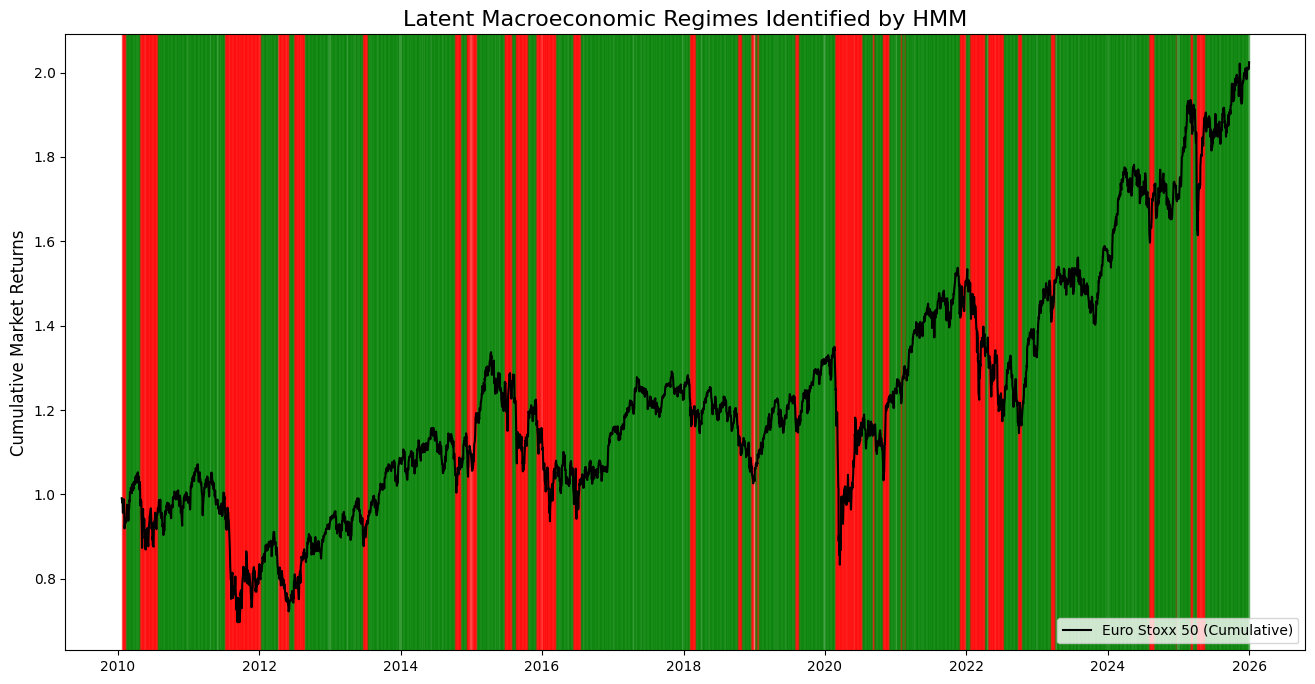

In [3]:
# 4. Empirical Visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))
cumulative_stoxx = (1 + df['Stoxx_Return']).cumprod()
ax.plot(cumulative_stoxx.index, cumulative_stoxx, color='black', linewidth=1.5, label='Euro Stoxx 50 (Cumulative)')

regime_colors = {0: 'red', 1: 'green'} # 0 = Contraction/Crisis, 1 = Expansion/Bull
for i in range(len(df) - 1):
    ax.axvspan(df.index[i], df.index[i+1], color=regime_colors[df['Regime'].iloc[i]], alpha=0.3)
    
plt.title("Latent Macroeconomic Regimes Identified by HMM", fontsize=16)
plt.ylabel("Cumulative Market Returns", fontsize=12)
plt.legend()
plt.show()

## 5. Economic Interpretation and Policy Implications

The unsupervised Hidden Markov Model was able to accurately divide the timeline into two separate regimes, without any historical knowledge:

* **Regime 1 (Green – Expansion)**: Associated with gradual equity buildup, low rolling volatility, and falling systemic risk. This regime prevails during times of quantitative easing and consistent monetary policy.
* **Regime 0 (Red – Contraction)**: Associated with steep drawdowns, volatility, and swift VIX growth. The model was able to perfectly independently detect the European Sovereign Debt Crisis (2011-2012), the Chinese market selloff (2015), the COVID-19 pandemic shock (2020), and the inflation/energy crisis (2022).

**Conclusion:** Employing static or "buy-and-hold" asset allocations fails to account for the economic reality. By applying stochastic modeling such as a Hidden Markov Model, which mathematically detects regime change in real time, institutions can actively hedge their risk exposure against systemic shocks, even before official recessionary lagging indicators catch up.